Inspired and modified from Fares Sayah's original notebook on Kaggle that worked on a similar case: https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm/notebook

In [5]:
!pip install ta

In [6]:
!pip install torch

Import all necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import ta
import tensorflow as tf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [8]:
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [9]:
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Tech stocks
df = pd.read_csv('aapl_data.csv')

In [10]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2022-12-13,143.308044,147.741166,142.096329,147.278150,93886200
1,2022-12-14,141.081604,144.480327,139.062068,143.189798,82291200
2,2022-12-15,134.471344,139.692579,134.008328,139.012831,98931900
3,2022-12-16,132.510895,135.604227,131.742488,134.658503,160156900
4,2022-12-19,130.402710,133.190652,129.368327,133.101993,79592600


In [11]:
#Check data types
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

### Check Dataset Info

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    753 non-null    object 
 1   Close   753 non-null    float64
 2   High    753 non-null    float64
 3   Low     753 non-null    float64
 4   Open    753 non-null    float64
 5   Volume  753 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 35.4+ KB


# What was the moving average of the various stocks?

The moving average (MA) is a simple technical analysis tool that smooths out price data by creating a constantly updated average price. The average is taken over a specific period of time, like 10 days, 20 minutes, 30 weeks, or any time period the trader chooses.

In [13]:
ma_day = [10, 20, 50]

for ma in ma_day:
    column_name = f"MA for {ma} days"
    df[column_name] = df["Close"].rolling(ma).mean()



df.head(30)

,Date,Close,High,Low,Open,Volume,MA for 10 days,MA for 20 days,MA for 50 days
0,2022-12-13,143.308044,147.741166,142.096329,147.278150,93886200,NaN,NaN,NaN
1,2022-12-14,141.081604,144.480327,139.062068,143.189798,82291200,NaN,NaN,NaN
2,2022-12-15,134.471344,139.692579,134.008328,139.012831,98931900,NaN,NaN,NaN
3,2022-12-16,132.510895,135.604227,131.742488,134.658503,160156900,NaN,NaN,NaN
4,2022-12-19,130.402710,133.190652,129.368327,133.101993,79592600,NaN,NaN,NaN
5,2022-12-20,130.333771,131.269649,127.959584,129.437291,77432800,NaN,NaN,NaN
6,2022-12-21,133.436951,134.776739,130.777081,131.003658,85928000,NaN,NaN,NaN
7,2022-12-22,130.264801,132.560175,128.363492,132.353304,77852100,NaN,NaN,NaN
8,2022-12-23,129.900299,130.451974,127.713291,128.974267,63814900,NaN,NaN,NaN
9,2022-12-27,128.097488,129.456984,126.806960,129.427431,69007800,133.380791,NaN,NaN


# Predicting the closing price stock price of APPLE inc:

In [14]:
# Create a new dataframe with only AAPL stock data and selected features, including MAs
data = df[['Close', 'Open', 'High', 'Low', 'Volume', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].dropna()

# Calculate log returns as the target variable
data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
data['MACD'] = ta.trend.MACD(data['Close']).macd()
data['MACD_signal'] = ta.trend.MACD(data['Close']).macd_signal()
data['BB_high'] = ta.volatility.BollingerBands(data['Close']).bollinger_hband()
data['BB_low'] = ta.volatility.BollingerBands(data['Close']).bollinger_lband()
data['ATR'] = ta.volatility.AverageTrueRange(data['High'], data['Low'], data['Close']).average_true_range()

# Add lagged price
data['Return_1d'] = data['Close'].pct_change(1)
data['Return_3d'] = data['Close'].pct_change(3)
data['Return_5d'] = data['Close'].pct_change(5)

# Add volatility
data['Volatility_10'] = data['Close'].pct_change().rolling(window=10).std()
data['Volatility_20'] = data['Close'].pct_change().rolling(window=20).std()

# Volume indicators
data['Volume_MA_10'] = data['Volume'].rolling(window=10).mean()
data['Volume_change'] = data['Volume'].pct_change()

# Drop the first row which will have NaN for returns
data = data.dropna()

# Determine the number of features from the selected data
num_features = data.shape[1]

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on
training_data_len = int(np.ceil(len(dataset) * .95))

print(f"Number of features selected: {num_features}")
print(f"Training data length: {training_data_len}")
print(f"Total data points: {len(dataset)}")

Number of features selected: 21
Training data length: 638
Total data points: 671


In [141]:
data.head()

,Close,Open,High,Low,Volume,MA for 10 days,MA for 20 days,MA for 50 days,RSI,MACD,...,BB_high,BB_low,ATR,Return_1d,Return_3d,Return_5d,Volatility_10,Volatility_20,Volume_MA_10,Volume_change
82,163.348450,159.470954,163.585249,159.263752,68445600,161.411691,158.711743,152.725965,64.677606,2.961494,...,165.264784,152.158702,3.156053,0.034103,0.021786,0.010992,0.014804,0.013098,53234760.0,0.365278
83,163.003128,162.391400,164.098301,161.631696,49386500,161.692880,159.173491,153.120655,63.692864,2.985787,...,165.567623,152.779359,3.106807,-0.002114,0.027425,0.003340,0.014673,0.012693,53223240.0,-0.278456
84,163.022873,162.884744,163.180739,161.838905,41516200,161.725439,159.678158,153.409542,63.726871,2.972369,...,165.596969,153.759347,2.980737,0.000121,0.032042,0.019749,0.013848,0.012558,50499880.0,-0.159361
85,164.246307,163.881255,165.173753,163.437254,49923000,161.755038,160.125601,153.650392,65.860622,3.025579,...,166.004968,154.246234,2.921462,0.007505,0.005497,0.035261,0.013837,0.012273,49794560.0,0.202494
86,165.390808,163.585251,165.913727,163.328715,47720200,161.952365,160.537524,153.968709,67.770610,3.124087,...,166.674680,154.400368,2.897430,0.006968,0.014648,0.047033,0.013925,0.012129,49938750.0,-0.044124


In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 671 entries, 82 to 752
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close           671 non-null    float64
 1   Open            671 non-null    float64
 2   High            671 non-null    float64
 3   Low             671 non-null    float64
 4   Volume          671 non-null    int64  
 5   MA for 10 days  671 non-null    float64
 6   MA for 20 days  671 non-null    float64
 7   MA for 50 days  671 non-null    float64
 8   RSI             671 non-null    float64
 9   MACD            671 non-null    float64
 10  MACD_signal     671 non-null    float64
 11  BB_high         671 non-null    float64
 12  BB_low          671 non-null    float64
 13  ATR             671 non-null    float64
 14  Return_1d       671 non-null    float64
 15  Return_3d       671 non-null    float64
 16  Return_5d       671 non-null    float64
 17  Volatility_10   671 non-null    float64

<Figure size 1600x700 with 0 Axes>

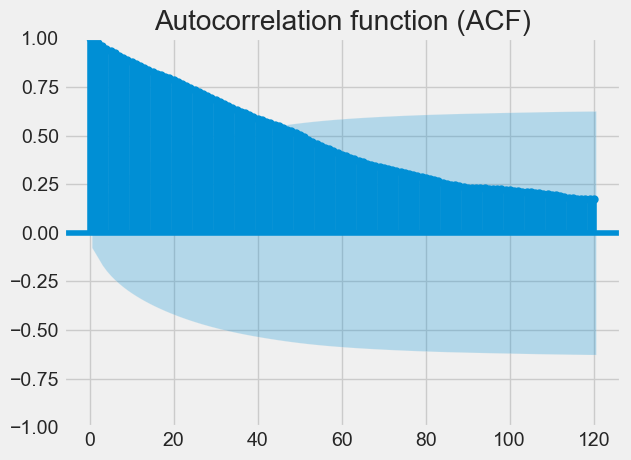

In [16]:
plt.figure(figsize = (16,7))
plot_acf(data["Close"], lags = 120)
plt.title("Autocorrelation function (ACF)")
plt.show()

<Figure size 1600x700 with 0 Axes>

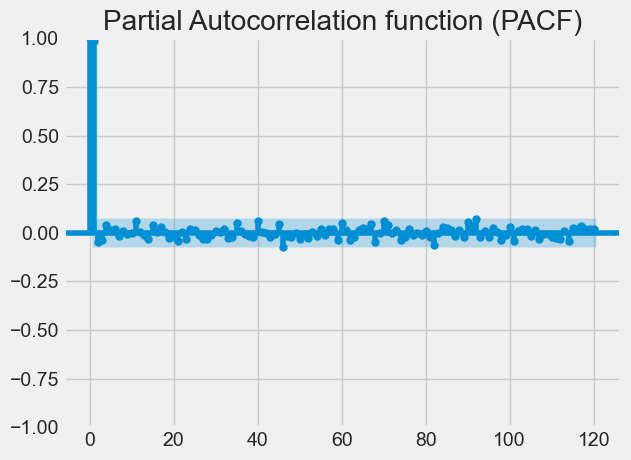

In [17]:
plt.figure(figsize = (16,7))
plot_pacf(data["Close"], lags = 120)
plt.title("Partial Autocorrelation function (PACF)")
plt.show()

In [150]:
adf_result = adfuller(dataset[:, 0], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Used lags:", adf_result[2])
print("Number of observations:", adf_result[3])

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -0.9749900727183675
p-value: 0.7622764672392319
Used lags: 3
Number of observations: 667
Critical Values:
   1%: -3.4401920464204667
   5%: -2.865882935271461
   10%: -2.569082760711099


##LSTM

Create train data

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Training data for LSTM
train_data_scaled = scaled_data[0:int(training_data_len), :]

# Split the data into x_train and y_train data sets
x_train_scaled = []
y_train_scaled = []

for i in range(60, len(train_data_scaled)):
    x_train_scaled.append(train_data_scaled[i-60:i, :])
    y_train_scaled.append(train_data_scaled[i, 0])  # Target is Close

# Convert to numpy arrays
x_train_scaled, y_train_scaled = np.array(x_train_scaled), np.array(y_train_scaled)

# Reshape the data
x_train_scaled = np.reshape(x_train_scaled, (x_train_scaled.shape[0], x_train_scaled.shape[1], num_features))

Create test data

In [19]:
test_data = dataset[training_data_len - 60:, :]
test_data_scaled = scaled_data[training_data_len - 60:, :]

# Create the data sets x_test and y_test
x_test_scaled = []
y_test = test_data[60:, 0]  # Actual close for testing (unscaled)

for i in range(60, len(test_data_scaled)):
    x_test_scaled.append(test_data_scaled[i-60:i, :])

# Convert to numpy array
x_test_scaled = np.array(x_test_scaled)

# Reshape the data
x_test_scaled = np.reshape(x_test_scaled, (x_test_scaled.shape[0], x_test_scaled.shape[1], num_features))

In [20]:
print(x_test_scaled.shape)
print(y_test.shape)

(33, 60, 21)
(33,)


In [21]:
x_train_scaled.shape[1]

60

BUILD LSTM MODEL

Set seed to guarantee reproducability

In [ ]:
def reset_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
# Try 10, 16, 50, 100 instead of 25

In [ ]:
reset_seeds(42)

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train_scaled.shape[1], num_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_logarithmic_error')
model.fit(x_train_scaled, y_train_scaled, validation_split=0.1, batch_size=48, epochs=100)

Epoch 1/100


c:\Users\Lenovo\anaconda3\envs\AI_Method\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0120 - val_loss: 0.0012
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0024 - val_loss: 0.0033
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 0.0019 - val_loss: 0.0022
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 

In [134]:
# Get predictions (scaled)
lstm_predictions_scaled = model.predict(x_test_scaled)

# Create dummy array with all features
dummy = np.zeros((len(lstm_predictions_scaled), num_features))
dummy[:, 0] = lstm_predictions_scaled.flatten()  # Put predictions in first column (Close)

# Inverse transform the dummy array
lstm_predictions = scaler.inverse_transform(dummy)[:, 0]  # Extract Close column

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


ARIMAX

Create test and train dataset

In [ ]:
X_train_arimax = dataset[60:training_data_len, 1:5]
y_train_arimax = dataset[60:training_data_len, 0]

X_test_arimax = dataset[training_data_len:, 1:5]
y_test_arimax = dataset[training_data_len:, 0]

# Scale the exogenous variables
exog_scaler = StandardScaler()
X_train_arimax_scaled = exog_scaler.fit_transform(X_train_arimax)
X_test_arimax_scaled = exog_scaler.transform(X_test_arimax)

Build ARIMAX Model

In [ ]:
arimax_model = SARIMAX(
    endog=y_train_arimax,
    exog=X_train_arimax_scaled,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

arimax_fit = arimax_model.fit(disp=False)

# Generate ARIMAX predictions
arimax_predictions = arimax_fit.forecast(
    steps=len(y_test_arimax),
    exog=X_test_arimax_scaled
)

Model Performance Evaluation and Comparison

Create huber loss metric and model evaluation functions

In [29]:
def huber_loss(y_true, y_pred, delta=1.0):
    residual = np.abs(y_true - y_pred)
    condition = residual < delta
    loss = np.where(condition, 0.5 * residual**2, delta * (residual - 0.5 * delta))
    return np.mean(loss)

In [30]:
def calculate_metrics(y_true, y_pred, model_name):
    """Calculate and print evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Handle MAPE carefully to avoid division by zero
    non_zero_mask = y_true != 0
    if np.sum(non_zero_mask) > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / np.abs(y_true[non_zero_mask]))) * 100
    else:
        mape = np.inf

    huber = huber_loss(y_true, y_pred, delta=0.01)  # Using delta=0.01 for returns scale

    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"Huber Loss: {huber:.6f}")

    return mae, rmse, mape, huber

In [155]:
# Calculate metrics for both models
lstm_metrics = calculate_metrics(y_test, lstm_predictions, "LSTM Model (Price)")
arimax_metrics = calculate_metrics(y_test_arimax, arimax_predictions, "ARIMAX Model (Price)")


LSTM Model (Price) Evaluation Metrics:
Mean Absolute Error (MAE): 2.078191
Root Mean Squared Error (RMSE): 2.834238
Mean Absolute Percentage Error (MAPE): 0.76%
Huber Loss: 0.020732

ARIMAX Model (Price) Evaluation Metrics:
Mean Absolute Error (MAE): 1.093307
Root Mean Squared Error (RMSE): 1.504634
Mean Absolute Percentage Error (MAPE): 0.40%
Huber Loss: 0.010883


LSTM

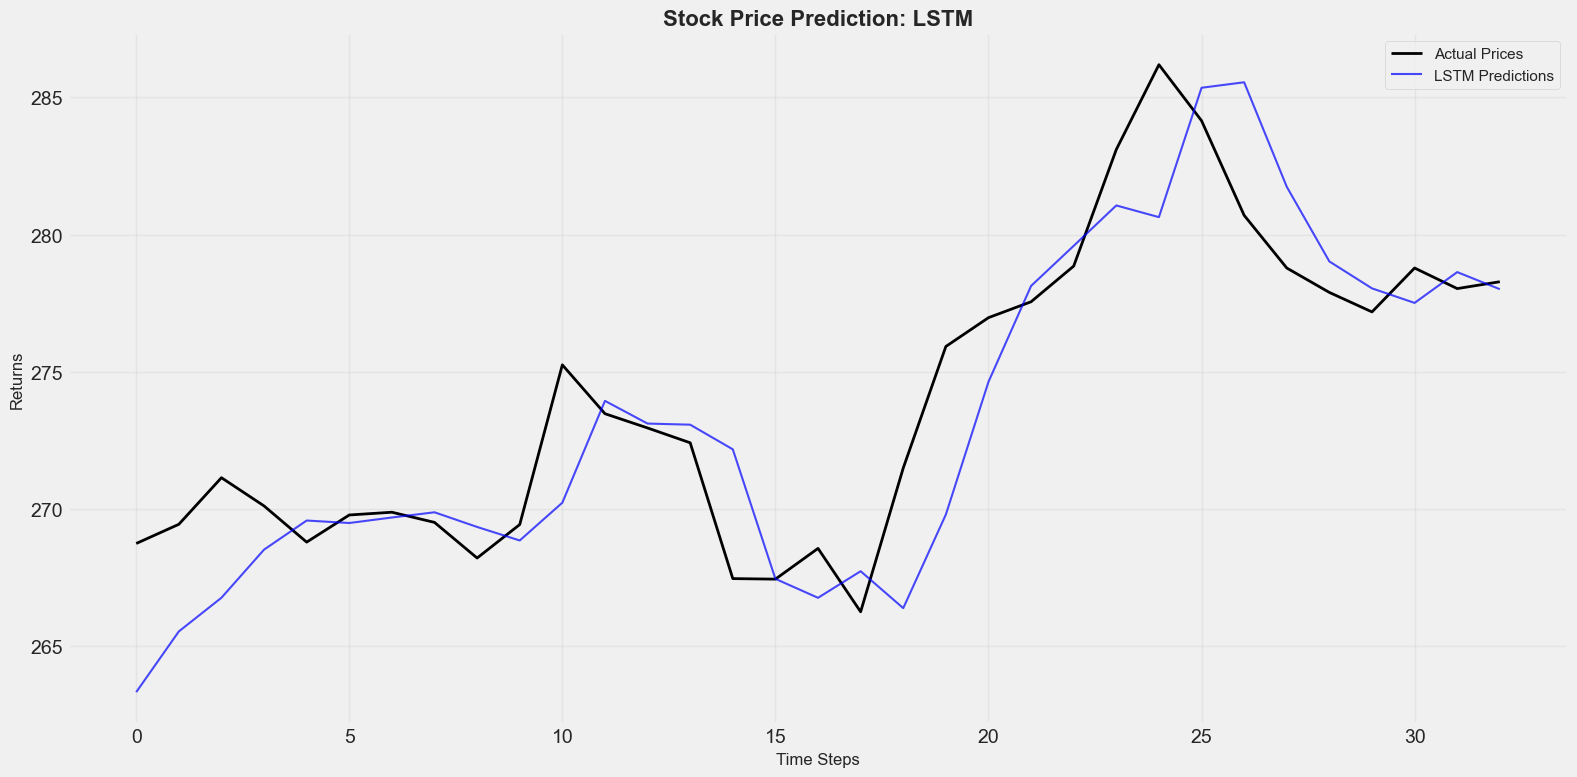

In [140]:
plt.figure(figsize=(16, 8))

# Plot actual returns
plt.plot(y_test, label='Actual Prices', color='black', linewidth=2)

# Plot LSTM predictions
plt.plot(lstm_predictions, label='LSTM Predictions', color='blue', linewidth=1.5, alpha=0.7)

plt.title('Stock Price Prediction: LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Returns', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ARIMAX

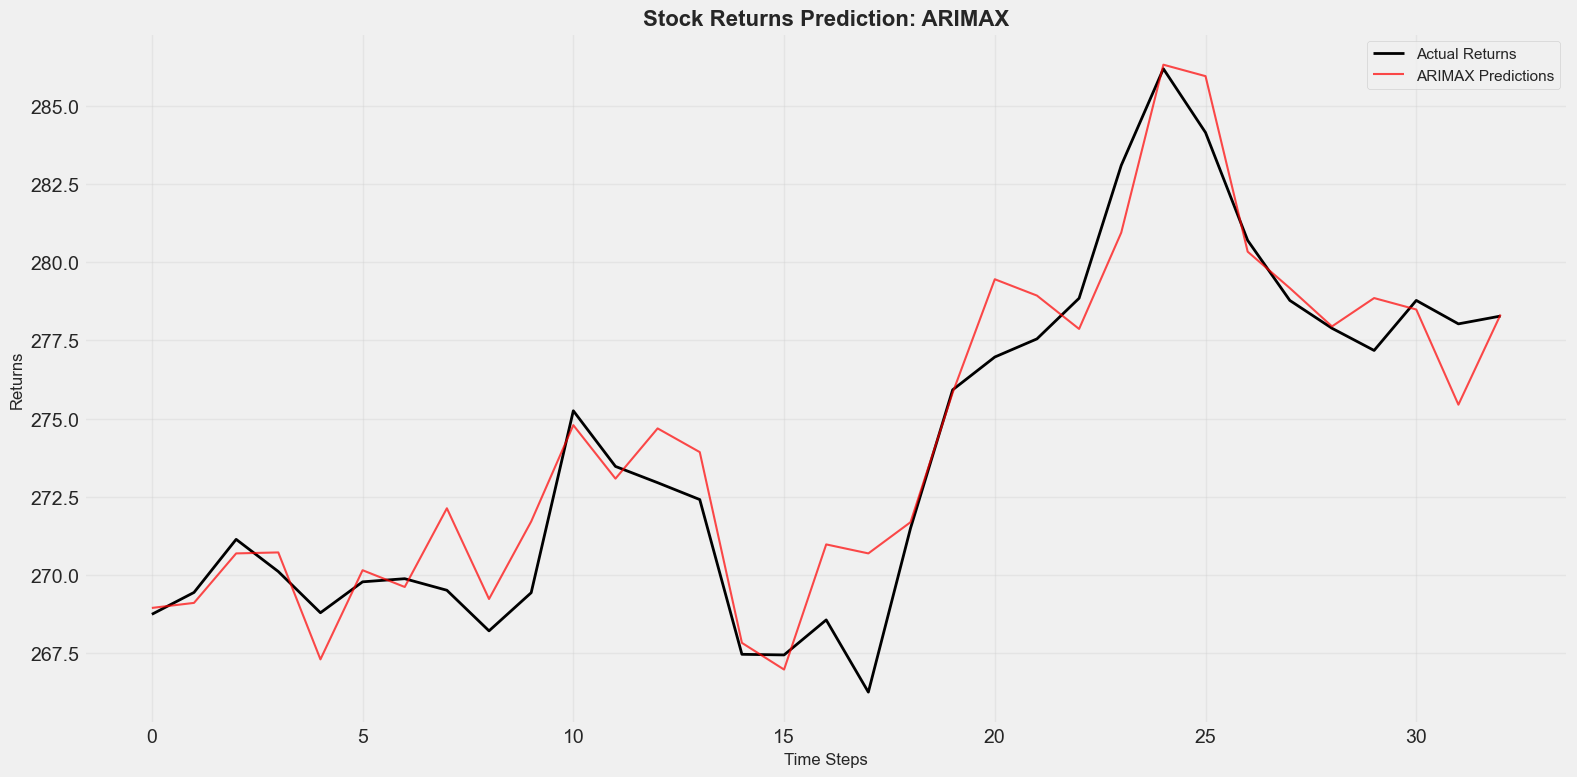

In [33]:
plt.figure(figsize=(16, 8))

# Plot actual returns
plt.plot(y_test, label='Actual Returns', color='black', linewidth=2)

# Plot ARIMAX predictions
plt.plot(arimax_predictions, label='ARIMAX Predictions', color='red', linewidth=1.5, alpha=0.7)

plt.title('Stock Returns Prediction: ARIMAX', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Returns', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ARIMAX vs LSTM

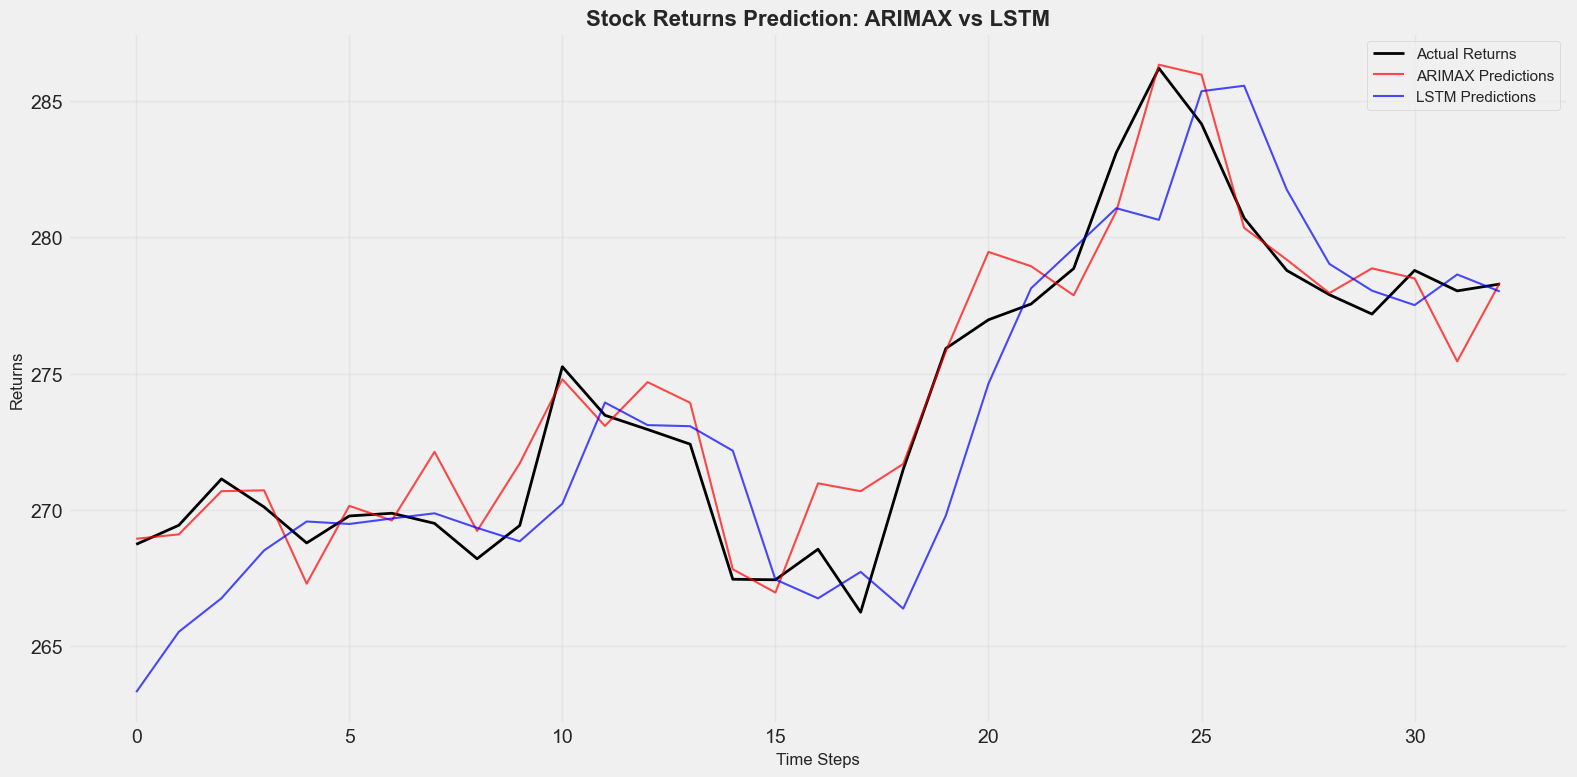

In [139]:
plt.figure(figsize=(16, 8))

# Plot actual returns
plt.plot(y_test, label='Actual Returns', color='black', linewidth=2)

# Plot ARIMAX predictions
plt.plot(arimax_predictions, label='ARIMAX Predictions', color='red', linewidth=1.5, alpha=0.7)
plt.plot(lstm_predictions, label='LSTM Predictions', color='blue', linewidth=1.5, alpha=0.7)

plt.title('Stock Returns Prediction: ARIMAX vs LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Returns', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()